In [13]:
import matplotlib.pyplot as plt
import pandas as pd


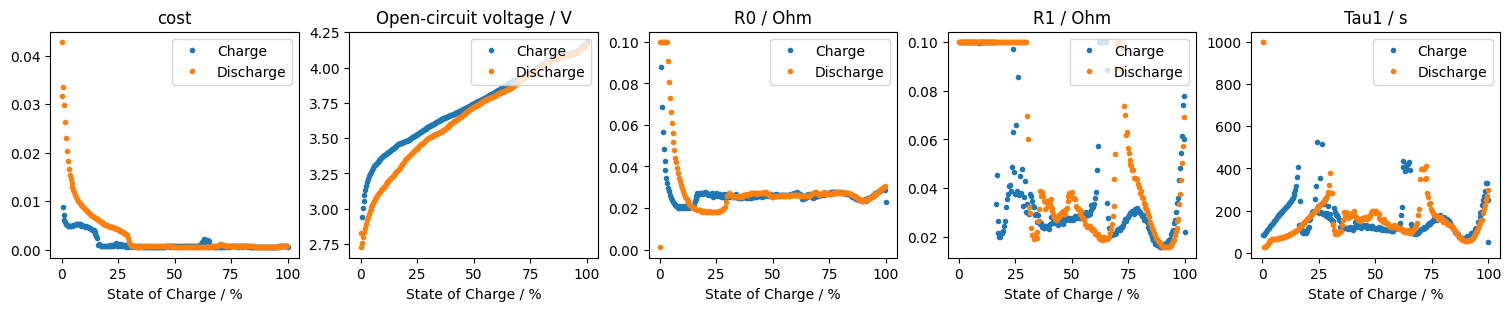

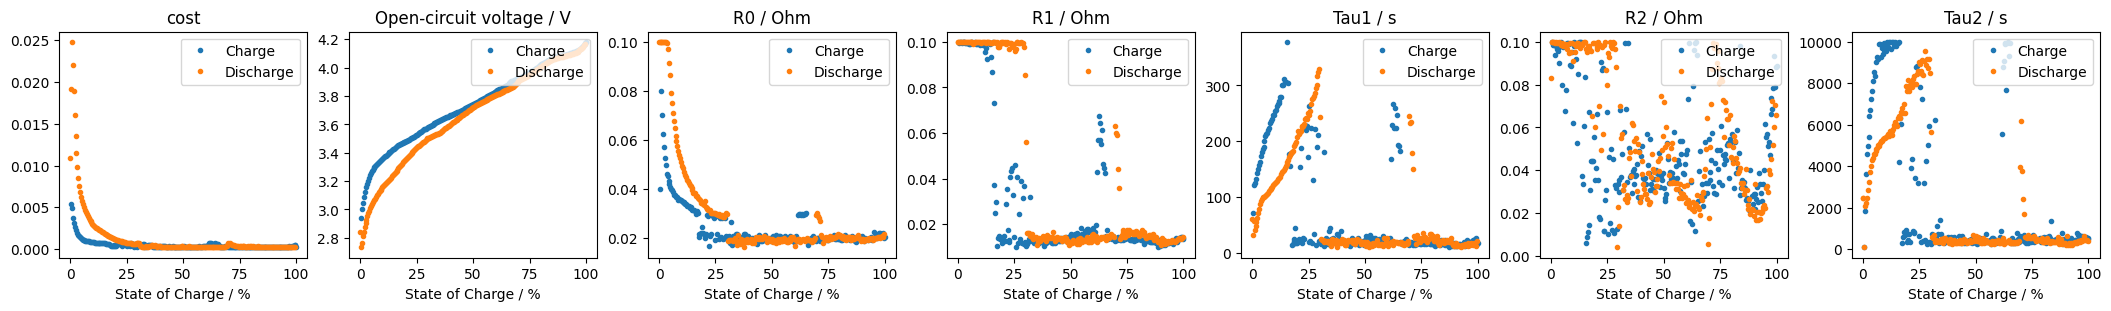

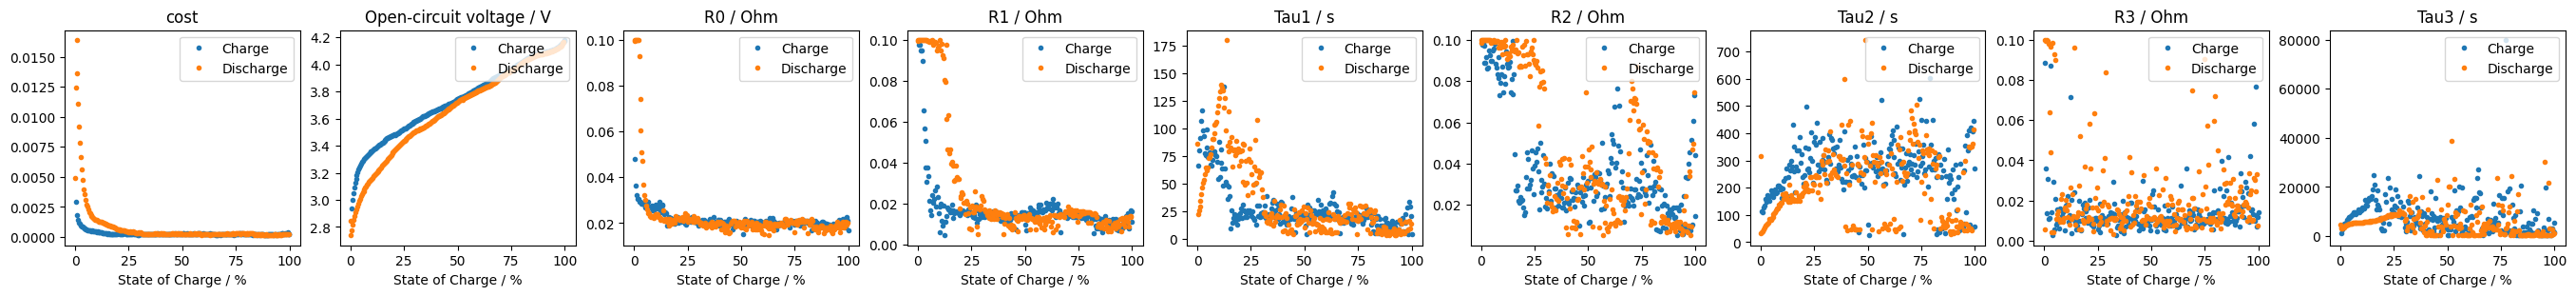

In [ ]:
def plot_param(n: int):
    param = (
        pd.read_csv(f"data/parameters_{n}.csv")
        .drop_duplicates()
        .sort_values(["Mode", "State of Charge / 1"], ascending=[False, True])
        .reset_index(drop=True)
    ).iloc[1::]

    keys = [
        "cost",
        "Open-circuit voltage / V",
        "R0 / Ohm",
    ]
    for i in range(1, n + 1):
        if f"R{i} / Ohm" in param.columns:
            keys.append(f"R{i} / Ohm")
        if f"Tau{i} / s" in param.columns:
            keys.append(f"Tau{i} / s")

    fig, axes = plt.subplots(
        nrows=1, ncols=len(keys), figsize=(3 * len(keys), 3), constrained_layout=True
    )
    for key in keys:
        for mode in ("Charge", "Discharge"):
            mask = param["Mode"] == mode
            x = param[mask]["State of Charge / 1"]
            y = param[mask][key]
            axes[keys.index(key)].plot(100 * x, y, label=mode, marker=".", ls="none")

        axes[keys.index(key)].set_title(key)
        axes[keys.index(key)].set_xlabel("State of Charge / %")
        axes[keys.index(key)].legend(loc="upper right")


for n in [1, 2, 3]:
    plot_param(n)